In [3]:
import numpy as np
import goes2go as goes
import pandas as pd
import matplotlib.pyplot as plt
import os
import random

from matplotlib import animation
from IPython import display

In [4]:
data_dir = '../data/train'
meta_path = '../data/train_metadata.csv'

In [5]:
# we first the datamethod in the paper where we just subtract band 15 - band 13 
# and then use that as the input

metadata = pd.read_csv(meta_path)
metadata.head()

,record_id,label
0,7829917977180135058,1
1,5319255125658459358,1
2,5747024955383921098,1
3,432548070956515051,1
4,3727988927537047897,1


In [6]:
# https://www.kaggle.com/code/vibhorsharma111/eda-model-train-submit#EDA

def get_band_images(idx: str, parent_folder: str, band: str):
    idx = str(idx)
    return np.load(os.path.join(parent_folder, idx, f'band_{band}.npy'))

def get_mask(idx: str, parent_folder: str):
    idx = str(idx)
    return np.load(os.path.join(parent_folder, idx, f'human_pixel_masks.npy'))

def get_mask_ind(idx: str, parent_folder: str):
    idx = str(idx)
    return np.load(os.path.join(parent_folder, idx, f'human_individual_masks.npy'))

_T11_BOUNDS = (243, 303)
_CLOUD_TOP_TDIFF_BOUNDS = (-4, 5)
_TDIFF_BOUNDS = (-4, 2)

def normalize_range(data, bounds):
    return (data - bounds[0]) / (bounds[1] - bounds[0])

def fake_color_img(idx, parent_folder, get_mask_frame_only=False):
    
    band11 = get_band_images(idx, parent_folder, '11')
    band14 = get_band_images(idx, parent_folder, '14')
    band15 = get_band_images(idx, parent_folder, '15')
    
    if get_mask_frame_only:
        band11 = band11[:,:,4]
        band14 = band14[:,:,4]
        band15 = band15[:,:,4]

    r = normalize_range(band15 - band14, _TDIFF_BOUNDS)
    g = normalize_range(band14 - band11, _CLOUD_TOP_TDIFF_BOUNDS)
    b = normalize_range(band14, _T11_BOUNDS)
    false_color = np.clip(np.stack([r, g, b], axis=2), 0, 1)
    return false_color


def btd_image(idx, parent_folder, get_mask_frame_only=False):
    
    band13 = get_band_images(idx, parent_folder, '13')
    band15 = get_band_images(idx, parent_folder, '15')
    
    if get_mask_frame_only:
        band13 = band13[:,:,4]
        band15 = band15[:,:,4]

    g = normalize_range(band13 - band15, _CLOUD_TOP_TDIFF_BOUNDS)
    false_color = np.clip(np.stack([r, g, b], axis=2), 0, 1)
    return false_color


829


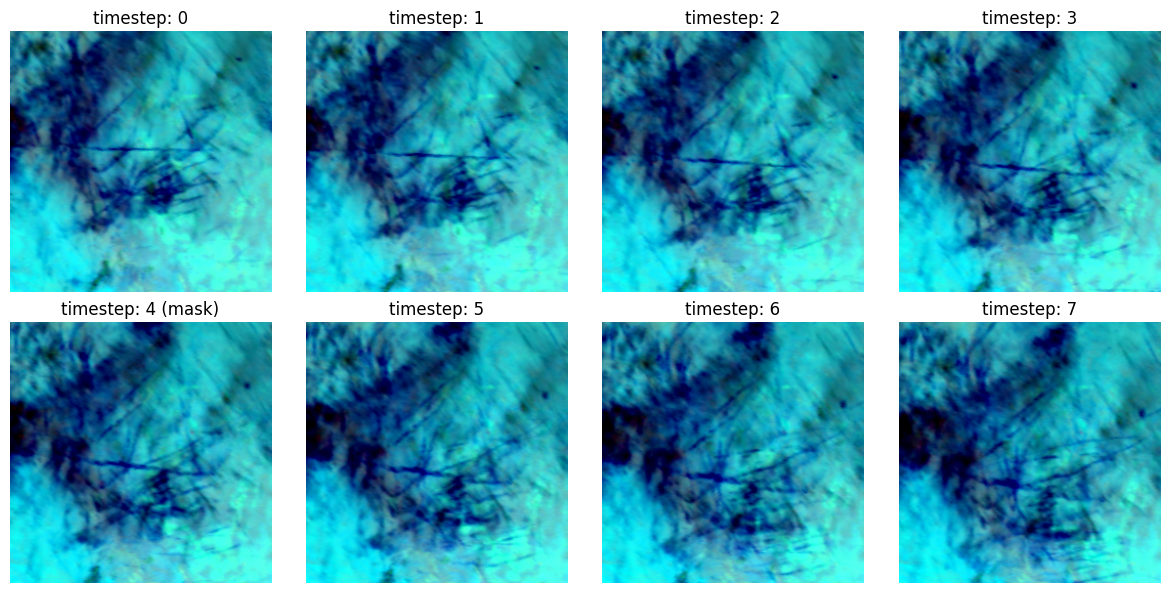

In [16]:
idx = random.randint(0, len(metadata)-1)
print(idx)
record_id = metadata.loc[idx]['record_id']
example_img = fake_color_img(record_id, data_dir)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(example_img[:, :, :, i])
    if i == 4: 
        ax.set_title(f'timestep: {i} (mask)')
    else:
        ax.set_title(f'timestep: {i}')
    ax.axis('off')
    
fig.tight_layout()

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

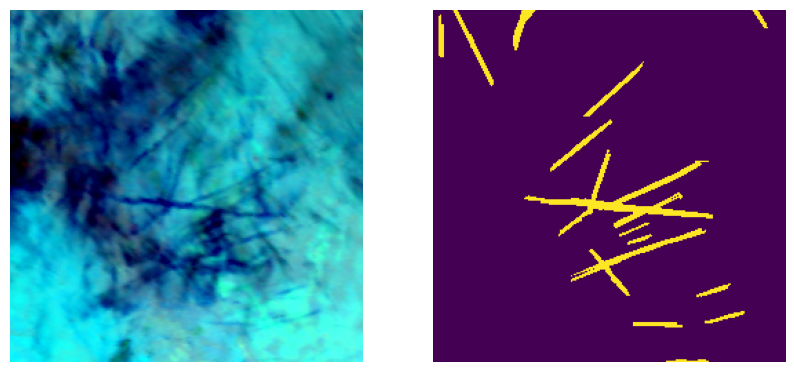

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(example_img[:, :, :, 4])
axes[0].axis('off')
axes[1].imshow(get_mask(record_id, data_dir))
axes[1].axis('off')

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_axis_off()
im = plt.imshow(example_img[..., 0])
def draw(i):
    im.set_array(example_img[..., i])
    return [im]
anim = animation.FuncAnimation(
    fig, draw, frames=example_img.shape[-1], interval=500, blit=True
)
plt.close()
display.HTML(anim.to_jshtml())


In [19]:
import h5py
import gc

# 1. Force the garbage collector to find unreferenced objects
gc.collect()

# 2. Try to catch and close any open H5 files in the local scope
# Note: This is a 'safety' loop
for obj in gc.get_objects():
    try:
        if isinstance(obj, h5py.File):
            obj.close()
            print("Closed a lingering H5 file handle.")
    except:
        pass

In [20]:
import os
import h5py
import numpy as np
from tqdm import tqdm

def create_raw_contrail_h5(data_dir, output_h5, record_ids):
    print(f"Creating {output_h5} with {len(record_ids)} records...")
    
    # Use 'a' (Append) so you can resume if the script stops
    with h5py.File(data_dir + output_h5, 'a', ) as f:
        for rid in tqdm(record_ids):
            # Skip if already in the file
            if rid in f:
                continue
            
            try:
                # 1. Load Raw Infrared Bands
                img_stack = fake_color_img(rid, data_dir)

                # 2. Load Masks
                # individual_masks is usually (256, 256, 6)
                indiv_masks = np.load(os.path.join(data_dir, rid, "human_individual_masks.npy"))
                # pixel_mask is (256, 256, 1)
                pixel_mask = np.load(os.path.join(data_dir, rid, "human_pixel_masks.npy"))

                # 3. Create Group and Datasets
                group = f.create_group(rid)
                
                # Using 'lzf' compression: it's nearly instant and 
                # significantly reduces the 5GB+ file size.
                group.create_dataset("image", data=img_stack, compression="lzf", chunks=(256, 256, 3, 8))
                group.create_dataset("individual_masks", data=indiv_masks, compression="lzf", chunks=(256, 256, 1, 4))
                group.create_dataset("pixel_mask", data=pixel_mask, compression="lzf", chunks=(256, 256, 1))
                
            except FileNotFoundError:
                print(f"Skipping {rid}: Files not found.")
            except Exception as e:
                print(f"Error on {rid}: {e}")

# Example Usage:
# my_record_ids = [folder for folder in os.listdir('/kaggle/input/train')]
# create_raw_contrail_h5('/kaggle/input/train', 'contrails_dataset.h5', my_record_ids)

In [21]:
create_raw_contrail_h5(data_dir, 'train_dataset.h5', metadata['record_id'].astype(str))

Creating train_dataset.h5 with 2400 records...


  0%|          | 7/2400 [00:00<05:15,  7.58it/s]


KeyboardInterrupt: 

In [ ]:
%%time
file = h5py.File('train_dataset.h5', 'r')

CPU times: total: 0 ns
Wall time: 652 μs


In [24]:
import os
import h5py
import numpy as np
from tqdm import tqdm

def create_fakeimgs(data_dir, record_ids):
    print(f"Creating fake imgs...")
   
    for rid in tqdm(record_ids):        
        try:
            img_stack = fake_color_img(rid, data_dir)
            np.save(data_dir + '/' + rid + '/ash_color_img.npy', img_stack)
            
        except FileNotFoundError:
            print(f"Skipping {rid}: Files not found.")
        except Exception as e:
            print(f"Error on {rid}: {e}")

# Example Usage:
# my_record_ids = [folder for folder in os.listdir('/kaggle/input/train')]
# create_raw_contrail_h5('/kaggle/input/train', 'contrails_dataset.h5', my_record_ids)

In [25]:
create_fakeimgs(data_dir, metadata['record_id'].astype(str))

Creating fake imgs...


100%|██████████| 2400/2400 [04:29<00:00,  8.89it/s]


In [26]:
def get_ash_image(idx: str, parent_folder: str = data_dir, get_mask_only: bool = False):
    idx = str(idx)
    img = np.load(os.path.join(parent_folder, idx, f'ash_color_img.npy'))
    return img

In [ ]:
%%time
for i in range(32):
    idx = str(metadata.loc[i]['record_id'])
    img = fake_color_img(idx, data_dir)
    label = get_mask(idx, data_dir)
    ind_mask = get_mask_ind(idx, data_dir)


CPU times: total: 359 ms
Wall time: 796 ms


In [ ]:
%%time
for i in range(32):
    idx = str(metadata.loc[i]['record_id'])
    img = file[idx]['image']
    label = file[idx]['pixel_mask']
    ind_mask = file[idx]['individual_masks']


CPU times: total: 15.6 ms
Wall time: 13.4 ms


In [26]:
import albumentations as A


train_transform = A.Compose([
            A.RandomRotate90(p=1),
            A.Affine(
                scale=(0.9, 1.1),
                rotate=(-15, 15),
                translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
                shear=(-5, 5),
                p=1,
            ),
            A.GaussNoise(p=0.2),
            A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.15, p=0.2),
        ])

In [27]:
image = example_img[:, :, :, 4]
pixel_mask = get_mask(record_id, data_dir)
soft_mask = get_mask_ind(record_id, data_dir).mean(axis=3)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

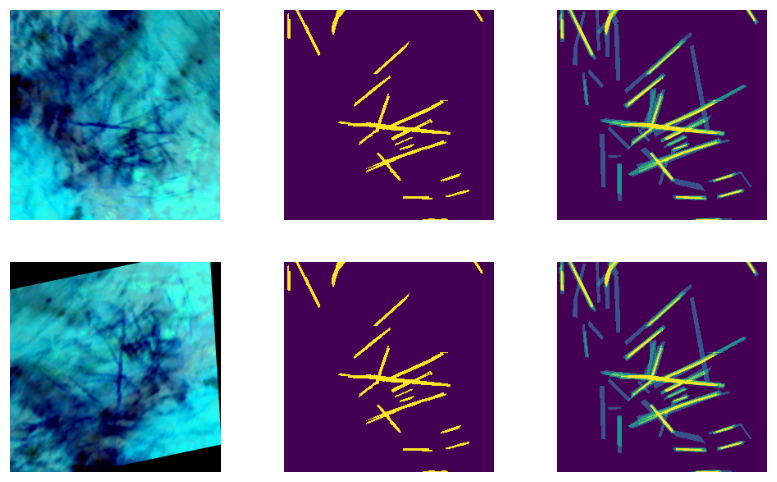

In [29]:
augmented = train_transform(image=image, target=pixel_mask, soft_target=soft_mask)
image_aug = augmented['image']
pixel_mask_aug = augmented['target']
soft_mask_aug = augmented['soft_target']

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes[0, 0].imshow(image)
axes[0, 0].axis('off')
axes[0, 1].imshow(pixel_mask)
axes[0, 1].axis('off')
axes[0, 2].imshow(soft_mask)
axes[0, 2].axis('off')

axes[1, 0].imshow(image_aug)
axes[1, 0].axis('off')
axes[1, 1].imshow(pixel_mask_aug)
axes[1, 1].axis('off')
axes[1, 2].imshow(soft_mask_aug)
axes[1, 2].axis('off')